In [2]:
!pip install seaborn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Fetch Telco Churn dataset directly from URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
print("=== DATASET SUMMARY ===")
print("Data Size (Rows, Columns):", df.shape)
print("\n5 First Line:")
display(df.head())

print("\nData Type & Missing Values ​​Information:")
print(df.info())

=== DATASET SUMMARY ===
Data Size (Rows, Columns): (7043, 21)

5 First Line:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Data Type & Missing Values ​​Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessB

In [10]:
# Change the TotalCharges column to numeric (blank spaces are changed to NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')

# Fill the empty TotalCharges value with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Number of missing values after cleaning:")
print(df.isnull().sum().sum())

Number of missing values after cleaning:
0


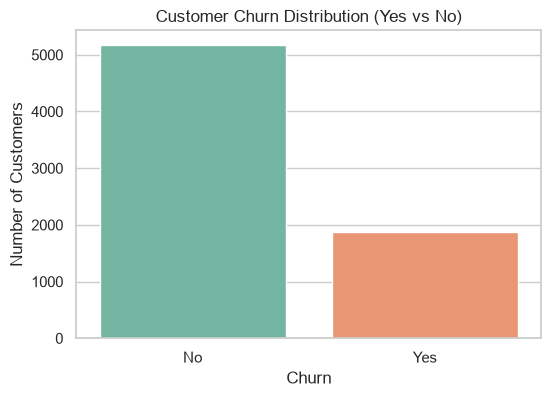

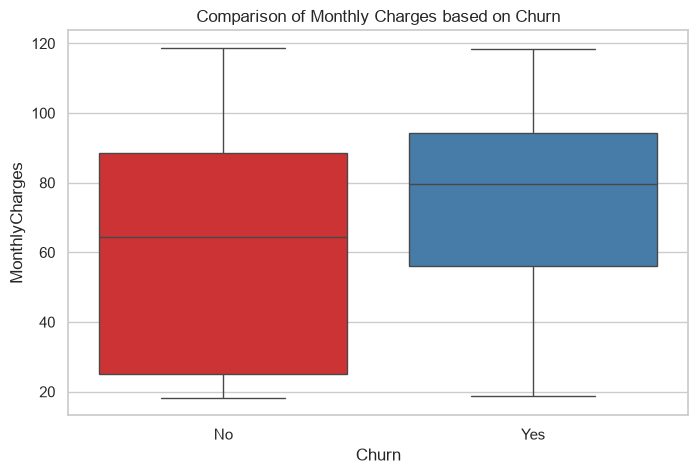

In [12]:
# Set graphic style
sns.set_theme(style="whitegrid")

# 1. Churn Distribution Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Customer Churn Distribution (Yes vs No)')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.savefig('distribusi_churn.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Grafik Boxplot MonthlyCharges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette='Set1', legend=False)
plt.title('Comparison of Monthly Charges based on Churn')
plt.savefig('boxplot_monthlycharges.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# T-Test to see if there is a difference in monthly costs between Churn vs No Churn customers
churn_yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
churn_no = df[df['Churn'] == 'No']['MonthlyCharges']

t_stat, p_value = stats.ttest_ind(churn_yes, churn_no)

print("=== HYPOTHESIS TESTING RESULTS ===")
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4e}")

if p_value < 0.05:
    print("\nConclusion: Reject H0.")
    print("This means that there is a statistically significant difference in the monthly costs of customers who churn vs. those who do not..")
else:
    print("\nConclusion: Failed to Reject H0.")

=== HYPOTHESIS TESTING RESULTS ===
T-Statistic : 16.5367
P-Value     : 2.7066e-60

Conclusion: Reject H0.
This means that there is a statistically significant difference in the monthly costs of customers who churn vs. those who do not..
